# AxisForge — Demonstração: Casos Reais C14 e H501

**Pipeline completo de análise — Phase 1**

Este notebook demonstra o pipeline do AxisForge em dois casos reais validados contra o GEARpie:

| Caso | Tipo | m | z₁/z₂ | β | x₁/x₂ | T₁ | n₁ |
|---|---|---|---|---|---|---|---|
| **C14** | Spur com desvio de perfil | 4.5 | 16/24 | 0° | 0.1817/0.1715 | 200 N·m | 1500 rpm |
| **H501** | Helicoidal com desvio de perfil | 3.5 | 20/30 | 15° | 0.1809/0.0891 | 100 N·m | 1000 rpm |

Ambos os casos têm al=91.5 mm. Forças validadas contra GEARpie (desvio <0.5%).

---
**Notas de limitação Phase 1:**
- Veios genéricos (dimensionados com base nas forças dos reports; não são os veios reais)
- Desvio de perfil suportado para geometria e forças; cálculo de x₁/x₂ óptimos → Phase 2
- Rolamentos: X=1, Y=0 (sem factores axiais ISO 281 Tab. 1)

In [ ]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, r"C:\Users\User\Documents\GitHub\AxisForge-Shaft-Bearing-Gear-System-Analysis-Platform\axisforge")

import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})

from core.shaft import Shaft, ShaftSection, Shoulder
from core.components import Bearing
from core.materials import S355, CrMo42
from core.system import MechanicalSystem
from solvers.gears.geometry import GearSolver
from solvers.shaft.statics import StaticsSolver
from solvers.shaft.static_failure import StaticFailureSolver
from solvers.shaft.stress import StressSolver
from solvers.bearings.life import BearingLifeSolver

gs = GearSolver()
print('✓ AxisForge pronto')

ModuleNotFoundError: No module named 'solvers.static_failure'

---
## CASO C14 — Engrenagem Reta com Desvio de Perfil
### C14-1. Geometria e Forças (GearSolver)

In [2]:
# ── C14: Geometria ─────────────────────────────────────────────────────────────
geo_c14 = gs.compute_geometry(
    mn=4.5, z1=16, z2=24,
    alpha_n_deg=20.0, beta_deg=0.0,
    al=91.5, x1=0.1817, x2=0.1715, b=20
)
forces_c14 = gs.compute_forces(T1_Nm=200.0, geometry=geo_c14)

print('GEOMETRIA C14')
print(f'  Módulo normal mn              = {geo_c14.mn} mm')
print(f'  Desvio de perfil x₁/x₂        = {geo_c14.x1}/{geo_c14.x2}')
print(f'  Centro standard a             = {geo_c14.a:.3f} mm')
print(f'  Centro de trabalho al         = {geo_c14.al:.3f} mm  (+{geo_c14.al-geo_c14.a:.3f} mm)')
print(f'  Ângulo de pressão de trab. αtw = {geo_c14.alpha_tw_deg:.4f}°  (vs αt={geo_c14.alpha_t_deg:.1f}°)')
print(f'  Diâm. referência d₁/d₂         = {geo_c14.d1:.3f}/{geo_c14.d2:.3f} mm')
print(f'  Diâm. trabalho dl₁/dl₂         = {geo_c14.dl1:.3f}/{geo_c14.dl2:.3f} mm')
print(f'  Diâm. cabeça da₁/da₂           = {geo_c14.da1:.3f}/{geo_c14.da2:.3f} mm')
print(f'  Diâm. base db₁/db₂             = {geo_c14.db1:.3f}/{geo_c14.db2:.3f} mm')
print(f'  Razão de contacto εα           = {geo_c14.eps_alpha:.4f}  (GEARpie: 1.46)')
print()
print('FORÇAS C14')
print(f'  Ft = {forces_c14.Ft:.1f} N   (GEARpie: 5464.5 N)  desvio={abs(forces_c14.Ft-5464.5)/5464.5*100:.2f}%')
print(f'  Fr = {forces_c14.Fr:.1f} N   (GEARpie: 2256.6 N)  desvio={abs(forces_c14.Fr-2256.6)/2256.6*100:.2f}%')
print(f'  Fa = {forces_c14.Fa:.1f} N   (spur → 0 exacto)')
print(f'  T₁ = {forces_c14.T1_Nmm/1000:.1f} N·m  T₂ = {forces_c14.T2_Nmm/1000:.1f} N·m')

GEOMETRIA C14
  Módulo normal mn              = 4.5 mm
  Desvio de perfil x₁/x₂        = 0.1817/0.1715
  Centro standard a             = 90.000 mm
  Centro de trabalho al         = 91.500 mm  (+1.500 mm)
  Ângulo de pressão de trab. αtw = 22.4388°  (vs αt=20.0°)
  Diâm. referência d₁/d₂         = 72.000/108.000 mm
  Diâm. trabalho dl₁/dl₂         = 73.200/109.800 mm
  Diâm. cabeça da₁/da₂           = 82.635/118.543 mm
  Diâm. base db₁/db₂             = 67.658/101.487 mm
  Razão de contacto εα           = 1.4624  (GEARpie: 1.46)

FORÇAS C14
  Ft = 5464.5 N   (GEARpie: 5464.5 N)  desvio=0.00%
  Fr = 2256.6 N   (GEARpie: 2256.6 N)  desvio=0.00%
  Fa = 0.0 N   (spur → 0 exacto)
  T₁ = 200.0 N·m  T₂ = 300.0 N·m


### C14-2. Sistema Mecânico e Análise Estática

In [3]:
# ── C14: Sistema ──────────────────────────────────────────────────────────────
# Veio genérico compatível com as forças C14
# d_central=60mm, d_extremos=50mm, 42CrMo4
# Ombros: shoulder_RIGHT de §1 (x=100mm) e shoulder_RIGHT de §2 (x=300mm)
# → shaft.shoulders() reporta apenas shoulder_right, garantindo avaliação de ambos
shaft_c14 = Shaft(name='C14_Shaft')
shaft_c14.add_section(ShaftSection(
    length=100.0, diameter=25.0, material_id='42CrMo4', label='§1'
    # sem shoulder_right aqui
))
shaft_c14.add_section(ShaftSection(
    length=200.0, diameter=30.0, material_id='42CrMo4', label='§2',
    shoulder_left =Shoulder(fillet_radius=2.5, diameter_large=30.0, diameter_small=25.0),
    shoulder_right=Shoulder(fillet_radius=2, diameter_large=30.0, diameter_small=20.0),
))
shaft_c14.add_section(ShaftSection(
    length=100.0, diameter=20.0, material_id='42CrMo4', label='§3'
))

sys_c14 = MechanicalSystem(shaft=shaft_c14, name='C14_System', speed_rpm=1500.0)
sys_c14.add_bearing(Bearing(position=50.0,  C=60_000.0, C0=38_000.0, arrangement='fixed',    label='A'))
sys_c14.add_bearing(Bearing(position=350.0, C=60_000.0, C0=38_000.0, arrangement='floating', label='B'))
sys_c14.add_gear(gs.to_gear_element(200.0, forces_c14, geo_c14, label='C14'))

# ── Estática ──────────────────────────────────────────────────────────────────
sr_c14 = StaticsSolver().solve(sys_c14)

r = sr_c14.reactions
print('REACÇÕES C14')
print(f'  A: XZ={r["A_xz"]:+.1f} N   XY={r["A_xy"]:+.1f} N   Fr_A={np.hypot(r["A_xz"],r["A_xy"]):.1f} N')
print(f'  B: XZ={r["B_xz"]:+.1f} N   XY={r["B_xy"]:+.1f} N   Fr_B={np.hypot(r["B_xz"],r["B_xy"]):.1f} N')
print(f'\n  M_res_max = {sr_c14.M_res_max:.0f} N·mm  em x={sr_c14.x_at_M_res_max:.1f} mm')
print(f'  T_max     = {sr_c14.T_max:.0f} N·mm')


REACÇÕES C14
  A: XZ=-2732.2 N   XY=-1128.3 N   Fr_A=2956.0 N
  B: XZ=-2732.2 N   XY=-1128.3 N   Fr_B=2956.0 N

  M_res_max = 442816 N·mm  em x=199.8 mm
  T_max     = 200000 N·mm


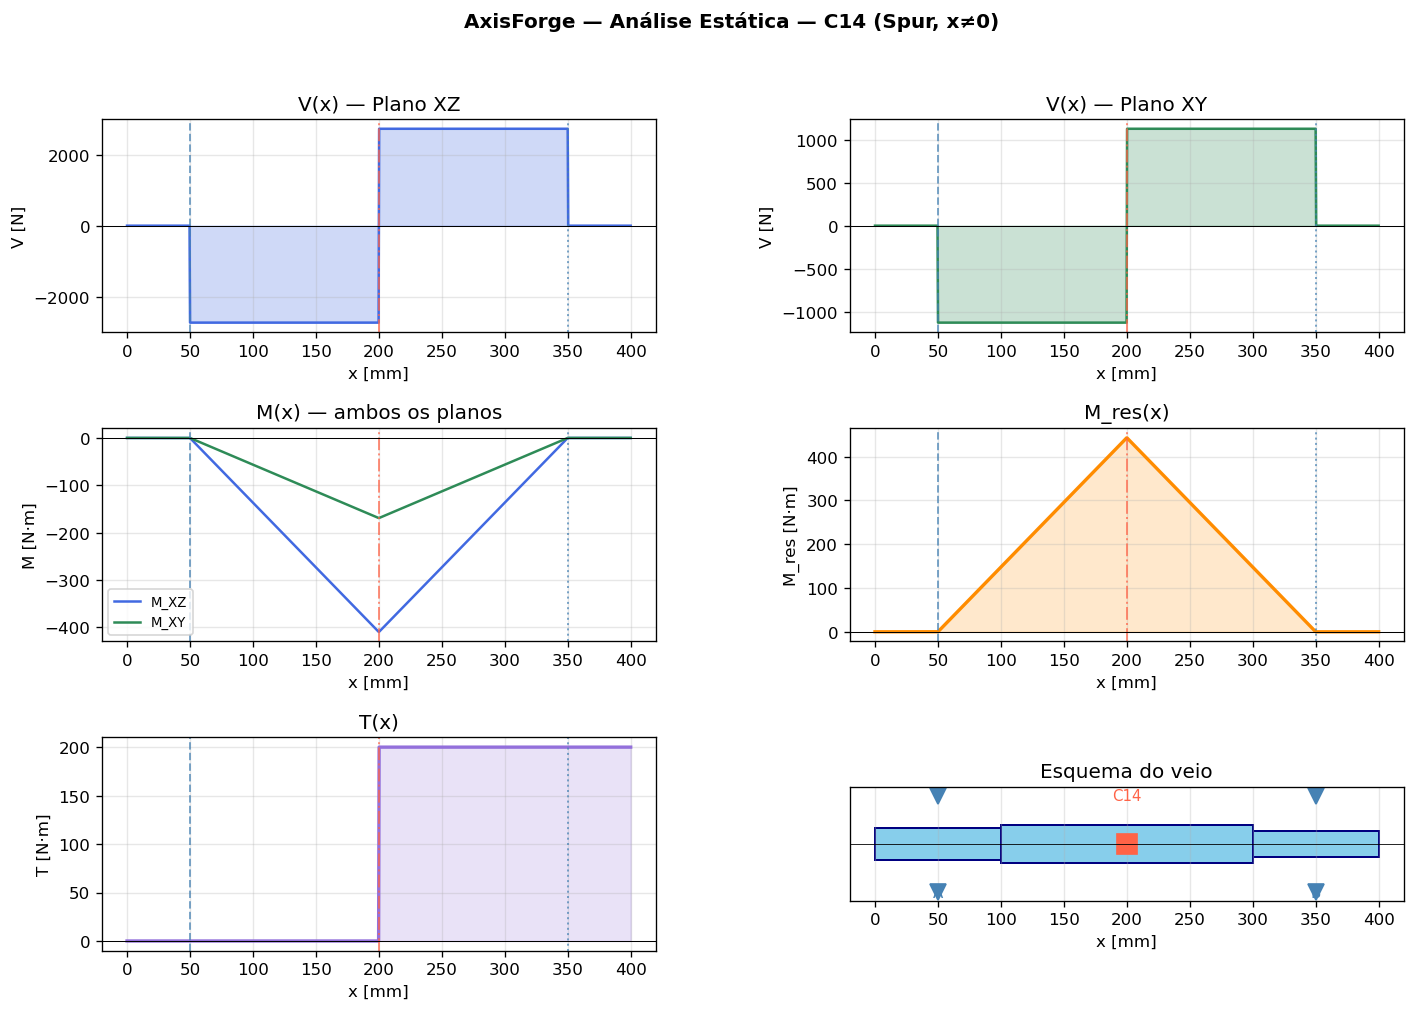

In [4]:
# ── C14: Diagramas ────────────────────────────────────────────────────────────
def plot_diagramas(sr, sys_obj, title, geo, forces):
    x = sr.x
    xA = sys_obj.bearings[0].position
    xB = sys_obj.bearings[1].position
    xG = sys_obj.gears[0].position

    fig = plt.figure(figsize=(14, 9))
    gs_p = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    def marks(ax):
        ax.axvline(xA, color='steelblue', lw=1.2, ls='--', alpha=0.7)
        ax.axvline(xB, color='steelblue', lw=1.2, ls=':',  alpha=0.7)
        ax.axvline(xG, color='tomato',    lw=1.2, ls='-.', alpha=0.7)
        ax.axhline(0,  color='k', lw=0.6)

    ax1 = fig.add_subplot(gs_p[0,0])
    ax1.fill_between(x, sr.V_xz, alpha=0.25, color='royalblue')
    ax1.plot(x, sr.V_xz, 'royalblue', lw=1.5); marks(ax1)
    ax1.set_title('V(x) — Plano XZ'); ax1.set_ylabel('V [N]'); ax1.set_xlabel('x [mm]')

    ax2 = fig.add_subplot(gs_p[0,1])
    ax2.fill_between(x, sr.V_xy, alpha=0.25, color='seagreen')
    ax2.plot(x, sr.V_xy, 'seagreen', lw=1.5); marks(ax2)
    ax2.set_title('V(x) — Plano XY'); ax2.set_ylabel('V [N]'); ax2.set_xlabel('x [mm]')

    ax3 = fig.add_subplot(gs_p[1,0])
    ax3.plot(x, sr.M_xz/1e3, 'royalblue', lw=1.5, label='M_XZ')
    ax3.plot(x, sr.M_xy/1e3, 'seagreen',  lw=1.5, label='M_XY')
    marks(ax3); ax3.legend(fontsize=8)
    ax3.set_title('M(x) — ambos os planos'); ax3.set_ylabel('M [N·m]'); ax3.set_xlabel('x [mm]')

    ax4 = fig.add_subplot(gs_p[1,1])
    ax4.fill_between(x, sr.M_res/1e3, alpha=0.2, color='darkorange')
    ax4.plot(x, sr.M_res/1e3, 'darkorange', lw=2); marks(ax4)
    ax4.set_title('M_res(x)'); ax4.set_ylabel('M_res [N·m]'); ax4.set_xlabel('x [mm]')

    ax5 = fig.add_subplot(gs_p[2,0])
    ax5.fill_between(x, sr.T/1e3, alpha=0.2, color='mediumpurple')
    ax5.plot(x, sr.T/1e3, 'mediumpurple', lw=2); marks(ax5)
    ax5.set_title('T(x)'); ax5.set_ylabel('T [N·m]'); ax5.set_xlabel('x [mm]')

    ax6 = fig.add_subplot(gs_p[2,1])
    ax6.set_xlim(-20, sys_obj.shaft.total_length+20)
    ax6.set_ylim(-45, 45); ax6.set_aspect('equal')
    secs = [(0,100,sys_obj.shaft.sections[0].diameter),
            (100,300,sys_obj.shaft.sections[1].diameter),
            (300,400,sys_obj.shaft.sections[2].diameter)]
    for x0,x1,d in secs:
        ax6.add_patch(plt.Rectangle((x0,-d/2), x1-x0, d, color='#87ceeb', ec='navy', lw=1.2))
    ax6.plot([xA,xA],[-38,38],'v',ms=10,color='steelblue')
    ax6.plot([xB,xB],[-38,38],'v',ms=10,color='steelblue')
    ax6.plot(xG, 0, 's', ms=12, color='tomato')
    ax6.text(xA,-42,'A',ha='center',fontsize=9,color='steelblue')
    ax6.text(xB,-42,'B',ha='center',fontsize=9,color='steelblue')
    ax6.text(xG, 35,sys_obj.gears[0].label,ha='center',fontsize=9,color='tomato')
    ax6.set_title('Esquema do veio'); ax6.set_xlabel('x [mm]'); ax6.set_yticks([])
    ax6.axhline(0, color='k', lw=0.5)

    fig.suptitle(f'AxisForge — {title}', fontsize=12, fontweight='bold')
    plt.show()

plot_diagramas(sr_c14, sys_c14, 'Análise Estática — C14 (Spur, x≠0)', geo_c14, forces_c14)

### C14-3. Fadiga e Falha Estática

In [5]:
# ── C14: Falha estática + Fadiga ──────────────────────────────────────────────
mat_c14 = CrMo42   # 42CrMo4: Sut=1000MPa, Sy=800MPa

sf_c14 = StaticFailureSolver().solve(sys_c14, sr_c14, mat_c14)
stress_c14 = StressSolver().solve(sys_c14, sr_c14, mat_c14, finish='machined', reliability_percent=99.0)

print(f'FALHA ESTÁTICA C14 — {mat_c14.material_id}  Sy={mat_c14.Sy} MPa')
print(f'{"x [mm]":>8} {"d [mm]":>7} {"σx [MPa]":>10} {"τxy [MPa]":>10} {"n_DE":>7} {"n_MSS":>7} {"Estado":>12}')
print('-'*65)
for s in sf_c14.sections:
    print(f'{s.x:>8.1f} {s.diameter:>7.1f} {s.sigma_x:>10.2f} {s.tau_xy:>10.2f} {s.n_DE:>7.2f} {s.n_MSS:>7.2f} {s.risk_label:>12}')

print(f'\nFADIGA C14 — Se_base={mat_c14.endurance_limit:.0f} MPa')
cs0 = stress_c14.sections[0]
print(f'  Se\' corrigido = {cs0.Se_prime:.1f} MPa  (ka={cs0.ka:.3f}, kb={cs0.kb:.3f}, ke={cs0.ke:.3f})')
print(f'{"x [mm]":>8} {"d":>5} {"Kt":>6} {"Kf":>6} {"σa [MPa]":>10} {"nf_Good":>9} {"nf_ASME":>9} {"ny":>7}')
print('-'*65)
for cs in stress_c14.sections:
    nfg = f'{cs.nf_goodman:.3f}' if cs.nf_goodman < 1e6 else '∞'
    nfa = f'{cs.nf_asme:.3f}'    if cs.nf_asme    < 1e6 else '∞'
    nyv = f'{cs.ny:.3f}'         if cs.ny          < 1e6 else '∞'
    print(f'{cs.x:>8.1f} {cs.diameter:>5.0f} {cs.Kt:>6.3f} {cs.Kf:>6.3f} {cs.sigma_a:>10.3f} {nfg:>9} {nfa:>9} {nyv:>7}')

mc = stress_c14.most_critical
print(f'\n✓ Secção mais crítica: x={mc.x:.0f}mm  nf_Goodman={mc.nf_goodman:.3f}  nf_ASME={mc.nf_asme:.3f}')

FALHA ESTÁTICA C14 — 42CrMo4  Sy=800.0 MPa
  x [mm]  d [mm]   σx [MPa]  τxy [MPa]    n_DE   n_MSS       Estado
-----------------------------------------------------------------
   300.0    20.0     188.19     127.32    2.76    2.53 conservative

FADIGA C14 — Se_base=500 MPa
  Se' corrigido = 264.8 MPa  (ka=0.723, kb=0.900, ke=0.814)
  x [mm]     d     Kt     Kf   σa [MPa]   nf_Good   nf_ASME      ny
-----------------------------------------------------------------
   300.0    20  1.600  1.533    288.431     0.735     0.877   2.023

✓ Secção mais crítica: x=300mm  nf_Goodman=0.735  nf_ASME=0.877


### C14-4. Vida dos Rolamentos

In [6]:
# ── C14: Rolamentos ───────────────────────────────────────────────────────────
bl = BearingLifeSolver()
bf_c14 = bl.extract_bearing_forces(sr_c14, sys_c14)

print(f'ROLAMENTOS C14  (n={sys_c14.speed_rpm:.0f} rpm, C=60kN, C0=38kN)')
print(f'{"":>4} {"Fr [N]":>8} {"Fa [N]":>8} {"P [N]":>8} {"L10h [h]":>10} {"S0":>6} {"Estado":>8}')
print('-'*60)
for bearing in sys_c14.bearings:
    Fr, Fa = bf_c14[bearing.label]
    res = bl.solve_bearing(bearing, Fr, Fa, sys_c14.speed_rpm, sys_c14.design_life_hours)
    estado = '✓ OK' if res.is_safe else '✗ FALHA'
    print(f'  {bearing.label}  {res.Fr:>8.1f} {res.Fa:>8.1f} {res.P:>8.1f} {res.L10h:>10.0f} {res.S0:>6.2f} {estado:>8}')

ROLAMENTOS C14  (n=1500 rpm, C=60kN, C0=38kN)
       Fr [N]   Fa [N]    P [N]   L10h [h]     S0   Estado
------------------------------------------------------------
  A    2956.0      0.0   2956.0      92913  21.42     ✓ OK
  B    2956.0      0.0   2956.0      92913  21.42     ✓ OK


---
## CASO H501 — Engrenagem Helicoidal com Desvio de Perfil
### H501-1. Geometria e Forças (GearSolver)

In [7]:
# ── H501: Geometria ────────────────────────────────────────────────────────────
geo_h501 = gs.compute_geometry(
    mn=3.5, z1=20, z2=30,
    alpha_n_deg=20.0, beta_deg=15.0,
    al=91.5, x1=0.1809, x2=0.0891, b=20
)
forces_h501 = gs.compute_forces(T1_Nm=100.0, geometry=geo_h501)

print('GEOMETRIA H501')
print(f'  Módulo normal mn              = {geo_h501.mn} mm')
print(f'  Módulo transversal mt         = {geo_h501.mt:.4f} mm')
print(f'  Ângulo de hélice β            = {geo_h501.beta_deg}°')
print(f'  Ângulo de hélice de base βb   = {geo_h501.beta_b_deg:.4f}°')
print(f'  Desvio de perfil x₁/x₂        = {geo_h501.x1}/{geo_h501.x2}')
print(f'  Centro standard a             = {geo_h501.a:.3f} mm')
print(f'  Centro de trabalho al         = {geo_h501.al:.3f} mm  (+{geo_h501.al-geo_h501.a:.3f} mm)')
print(f'  Ângulo de pressão de trab. αtw = {geo_h501.alpha_tw_deg:.4f}°')
print(f'  Passo de base transversal pbt  = {geo_h501.p_bt:.4f} mm  (GEARpie: 10.652)')
print(f'  Razão de contacto εα          = {geo_h501.eps_alpha:.4f}  (GEARpie: 1.46)')
print(f'  Razão de contacto εβ          = {geo_h501.eps_beta:.4f}  (b não fornecido → 0)')
print()
print('FORÇAS H501')
print(f'  Ft = {forces_h501.Ft:.1f} N   (GEARpie: 2732.2 N)  desvio={abs(forces_h501.Ft-2732.2)/2732.2*100:.2f}%')
print(f'  Fr = {forces_h501.Fr:.1f} N   (GEARpie: 1110.3 N)  desvio={abs(forces_h501.Fr-1110.3)/1110.3*100:.2f}%')
print(f'  Fa = {forces_h501.Fa:.1f} N   (GEARpie:  739.5 N)  desvio={abs(forces_h501.Fa-739.5)/739.5*100:.2f}%')
print(f'  T₁ = {forces_h501.T1_Nmm/1000:.1f} N·m  T₂ = {forces_h501.T2_Nmm/1000:.1f} N·m')

GEOMETRIA H501
  Módulo normal mn              = 3.5 mm
  Módulo transversal mt         = 3.6235 mm
  Ângulo de hélice β            = 15.0°
  Ângulo de hélice de base βb   = 14.0761°
  Desvio de perfil x₁/x₂        = 0.1809/0.0891
  Centro standard a             = 90.587 mm
  Centro de trabalho al         = 91.500 mm  (+0.913 mm)
  Ângulo de pressão de trab. αtw = 22.1149°
  Passo de base transversal pbt  = 10.6523 mm  (GEARpie: 10.652)
  Razão de contacto εα          = 1.4716  (GEARpie: 1.46)
  Razão de contacto εβ          = 0.4708  (b não fornecido → 0)

FORÇAS H501
  Ft = 2732.2 N   (GEARpie: 2732.2 N)  desvio=0.00%
  Fr = 1110.3 N   (GEARpie: 1110.3 N)  desvio=0.00%
  Fa = 739.5 N   (GEARpie:  739.5 N)  desvio=0.00%
  T₁ = 100.0 N·m  T₂ = 150.0 N·m


### H501-2. Sistema Mecânico e Análise Estática

In [8]:
# ── H501: Sistema ─────────────────────────────────────────────────────────────
# Ombros: shoulder_RIGHT de §1 (x=100mm) e shoulder_RIGHT de §2 (x=300mm)
shaft_h501 = Shaft(name='H501_Shaft')
shaft_h501.add_section(ShaftSection(
    length=100.0, diameter=25.0, material_id='42CrMo4', label='§1',
))
shaft_h501.add_section(ShaftSection(
    length=200.0, diameter=30.0, material_id='42CrMo4', label='§2',
    shoulder_left =Shoulder(fillet_radius=2.5, diameter_large=30.0, diameter_small=25.0),
    shoulder_right=Shoulder(fillet_radius=2.5, diameter_large=30.0, diameter_small=25.0),
))
shaft_h501.add_section(ShaftSection(length=100.0, diameter=25.0, material_id='42CrMo4', label='§3'))

sys_h501 = MechanicalSystem(shaft=shaft_h501, name='H501_System', speed_rpm=1000.0)
sys_h501.add_bearing(Bearing(position=50.0,  C=35_000.0, C0=22_000.0, arrangement='fixed',    label='A'))
sys_h501.add_bearing(Bearing(position=350.0, C=35_000.0, C0=22_000.0, arrangement='floating', label='B'))
sys_h501.add_gear(gs.to_gear_element(200.0, forces_h501, geo_h501, label='H501'))

sr_h501 = StaticsSolver().solve(sys_h501)

r = sr_h501.reactions
print('REACÇÕES H501')
print(f'  A: XZ={r["A_xz"]:+.1f} N   XY={r["A_xy"]:+.1f} N   Fr_A={np.hypot(r["A_xz"],r["A_xy"]):.1f} N')
print(f'  B: XZ={r["B_xz"]:+.1f} N   XY={r["B_xy"]:+.1f} N   Fr_B={np.hypot(r["B_xz"],r["B_xy"]):.1f} N')
print(f'  Axial (rolamento fixo A): {abs(r["axial"]):.1f} N  (Fa={forces_h501.Fa:.1f} N)')
print(f'\n  M_res_max = {sr_h501.M_res_max:.0f} N·mm  em x={sr_h501.x_at_M_res_max:.1f} mm')
print(f'  T_max     = {sr_h501.T_max:.0f} N·mm')


REACÇÕES H501
  A: XZ=-1366.1 N   XY=-555.1 N   Fr_A=1474.6 N
  B: XZ=-1366.1 N   XY=-555.1 N   Fr_B=1474.6 N
  Axial (rolamento fixo A): 739.5 N  (Fa=739.5 N)

  M_res_max = 220896 N·mm  em x=199.8 mm
  T_max     = 100000 N·mm


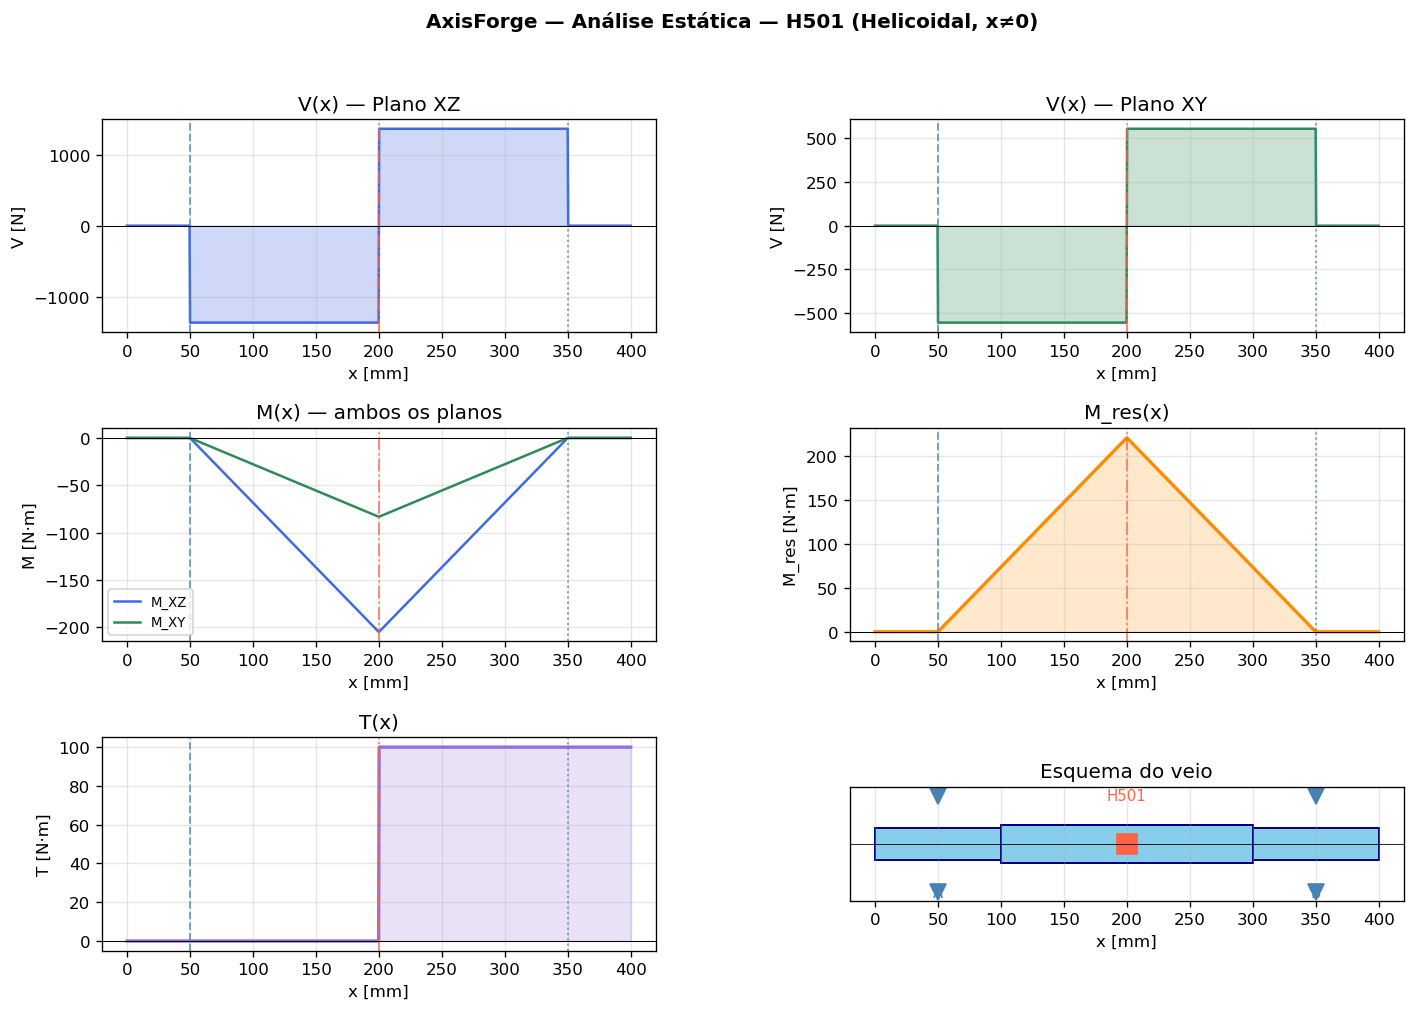

In [9]:
plot_diagramas(sr_h501, sys_h501, 'Análise Estática — H501 (Helicoidal, x≠0)', geo_h501, forces_h501)

### H501-3. Fadiga e Falha Estática

In [10]:
mat_h501 = CrMo42

sf_h501 = StaticFailureSolver().solve(sys_h501, sr_h501, mat_h501)
stress_h501 = StressSolver().solve(sys_h501, sr_h501, mat_h501, finish='machined', reliability_percent=99.0)

print(f'FALHA ESTÁTICA H501 — {mat_h501.material_id}  Sy={mat_h501.Sy} MPa')
print(f'{"x [mm]":>8} {"d [mm]":>7} {"σx [MPa]":>10} {"τxy [MPa]":>10} {"n_DE":>7} {"n_MSS":>7} {"Estado":>12}')
print('-'*65)
for s in sf_h501.sections:
    print(f'{s.x:>8.1f} {s.diameter:>7.1f} {s.sigma_x:>10.2f} {s.tau_xy:>10.2f} {s.n_DE:>7.2f} {s.n_MSS:>7.2f} {s.risk_label:>12}')

print(f'\nFADIGA H501')
cs0 = stress_h501.sections[0]
print(f'  Se\' corrigido = {cs0.Se_prime:.1f} MPa')
print(f'{"x [mm]":>8} {"d":>5} {"Kt":>6} {"Kf":>6} {"σa [MPa]":>10} {"nf_Good":>9} {"nf_ASME":>9} {"ny":>7}')
print('-'*65)
for cs in stress_h501.sections:
    nfg = f'{cs.nf_goodman:.3f}' if cs.nf_goodman < 1e6 else '∞'
    nfa = f'{cs.nf_asme:.3f}'    if cs.nf_asme    < 1e6 else '∞'
    nyv = f'{cs.ny:.3f}'         if cs.ny          < 1e6 else '∞'
    print(f'{cs.x:>8.1f} {cs.diameter:>5.0f} {cs.Kt:>6.3f} {cs.Kf:>6.3f} {cs.sigma_a:>10.3f} {nfg:>9} {nfa:>9} {nyv:>7}')

mc = stress_h501.most_critical
print(f'\n✓ Secção mais crítica: x={mc.x:.0f}mm  nf_Goodman={mc.nf_goodman:.3f}  nf_ASME={mc.nf_asme:.3f}')

FALHA ESTÁTICA H501 — 42CrMo4  Sy=800.0 MPa
  x [mm]  d [mm]   σx [MPa]  τxy [MPa]    n_DE   n_MSS       Estado
-----------------------------------------------------------------
   300.0    25.0      48.06      32.59   10.79    9.88 conservative

FADIGA H501
  Se' corrigido = 258.6 MPa
  x [mm]     d     Kt     Kf   σa [MPa]   nf_Good   nf_ASME      ny
-----------------------------------------------------------------
   300.0    25  1.600  1.539     73.974     2.813     3.345   7.887

✓ Secção mais crítica: x=300mm  nf_Goodman=2.813  nf_ASME=3.345


### H501-4. Vida dos Rolamentos

In [11]:
bf_h501 = bl.extract_bearing_forces(sr_h501, sys_h501)

print(f'ROLAMENTOS H501  (n={sys_h501.speed_rpm:.0f} rpm, C=35kN, C0=22kN)')
print(f'  Nota: rolamento A (fixo) absorve Fa={forces_h501.Fa:.1f} N axial da engrenagem helicoidal')
print(f'{"":>4} {"Fr [N]":>8} {"Fa [N]":>8} {"P [N]":>8} {"L10h [h]":>10} {"S0":>6} {"Estado":>8}')
print('-'*60)
for bearing in sys_h501.bearings:
    Fr, Fa = bf_h501[bearing.label]
    res = bl.solve_bearing(bearing, Fr, Fa, sys_h501.speed_rpm, sys_h501.design_life_hours)
    estado = '✓ OK' if res.is_safe else '✗ FALHA'
    print(f'  {bearing.label}  {res.Fr:>8.1f} {res.Fa:>8.1f} {res.P:>8.1f} {res.L10h:>10.0f} {res.S0:>6.2f} {estado:>8}')

ROLAMENTOS H501  (n=1000 rpm, C=35kN, C0=22kN)
  Nota: rolamento A (fixo) absorve Fa=739.5 N axial da engrenagem helicoidal
       Fr [N]   Fa [N]    P [N]   L10h [h]     S0   Estado
------------------------------------------------------------
  A    1474.6    739.5   1474.6     222856  17.54     ✓ OK
  B    1474.6      0.0   1474.6     222856  24.87     ✓ OK


---
## Comparação C14 vs H501

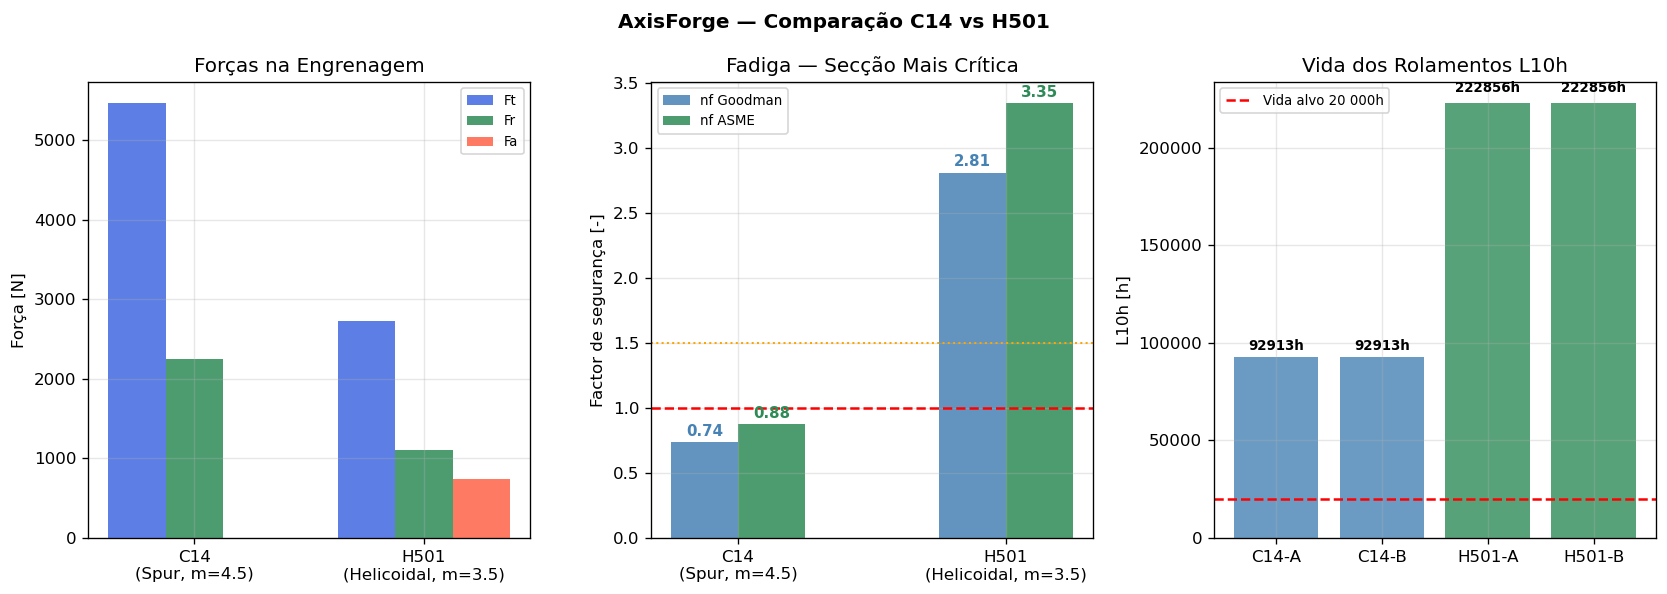

In [12]:
# ── Comparação visual C14 vs H501 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

casos = ['C14\n(Spur, m=4.5)', 'H501\n(Helicoidal, m=3.5)']
cores = ['steelblue', 'seagreen']

# Forças
ax = axes[0]
x_pos = np.array([0, 1])
Fts = [forces_c14.Ft, forces_h501.Ft]
Frs = [forces_c14.Fr, forces_h501.Fr]
Fas = [forces_c14.Fa, forces_h501.Fa]
w = 0.25
ax.bar(x_pos-w, Fts, w, label='Ft', color='royalblue', alpha=0.85)
ax.bar(x_pos,   Frs, w, label='Fr', color='seagreen',  alpha=0.85)
ax.bar(x_pos+w, Fas, w, label='Fa', color='tomato',    alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(casos)
ax.set_ylabel('Força [N]'); ax.set_title('Forças na Engrenagem')
ax.legend(fontsize=8)

# nf Goodman
ax2 = axes[1]
mc_c14  = stress_c14.most_critical
mc_h501 = stress_h501.most_critical
nfs_g = [mc_c14.nf_goodman  if mc_c14.nf_goodman  < 1e6 else 0,
         mc_h501.nf_goodman if mc_h501.nf_goodman < 1e6 else 0]
nfs_a = [mc_c14.nf_asme     if mc_c14.nf_asme     < 1e6 else 0,
         mc_h501.nf_asme    if mc_h501.nf_asme    < 1e6 else 0]
ax2.bar(x_pos-w/2, nfs_g, w, label='nf Goodman', color='steelblue', alpha=0.85)
ax2.bar(x_pos+w/2, nfs_a, w, label='nf ASME',    color='seagreen',  alpha=0.85)
ax2.axhline(1.0, color='red',    ls='--', lw=1.5)
ax2.axhline(1.5, color='orange', ls=':',  lw=1.2)
for i,(g,a) in enumerate(zip(nfs_g,nfs_a)):
    if g>0: ax2.text(i-w/2, g+0.05, f'{g:.2f}', ha='center', fontsize=9, color='steelblue', fontweight='bold')
    if a>0: ax2.text(i+w/2, a+0.05, f'{a:.2f}', ha='center', fontsize=9, color='seagreen',  fontweight='bold')
ax2.set_xticks(x_pos); ax2.set_xticklabels(casos)
ax2.set_ylabel('Factor de segurança [-]')
ax2.set_title('Fadiga — Secção Mais Crítica')
ax2.legend(fontsize=8)

# L10h
ax3 = axes[2]
l10h_c14_A  = bl.solve_bearing(sys_c14.bearings[0],  *bf_c14['A'],  sys_c14.speed_rpm,  20000).L10h
l10h_c14_B  = bl.solve_bearing(sys_c14.bearings[1],  *bf_c14['B'],  sys_c14.speed_rpm,  20000).L10h
l10h_h501_A = bl.solve_bearing(sys_h501.bearings[0], *bf_h501['A'], sys_h501.speed_rpm, 20000).L10h
l10h_h501_B = bl.solve_bearing(sys_h501.bearings[1], *bf_h501['B'], sys_h501.speed_rpm, 20000).L10h
labels_r = ['C14-A','C14-B','H501-A','H501-B']
vals_r   = [l10h_c14_A, l10h_c14_B, l10h_h501_A, l10h_h501_B]
cols_r   = ['steelblue','steelblue','seagreen','seagreen']
bars = ax3.bar(labels_r, vals_r, color=cols_r, alpha=0.8)
ax3.axhline(20000, color='red', ls='--', lw=1.5, label='Vida alvo 20 000h')
for bar, val in zip(bars, vals_r):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
             f'{val:.0f}h', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax3.set_ylabel('L10h [h]'); ax3.set_title('Vida dos Rolamentos L10h')
ax3.legend(fontsize=8)

fig.suptitle('AxisForge — Comparação C14 vs H501', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sumário

In [13]:
for nome, geo, forces, sr, stress, sf, sys_obj in [
    ('C14', geo_c14, forces_c14, sr_c14, stress_c14, sf_c14, sys_c14),
    ('H501', geo_h501, forces_h501, sr_h501, stress_h501, sf_h501, sys_h501),
]:
    mc = stress.most_critical
    sfc = sf.critical_section
    print('='*58)
    print(f' {nome}  |  {sys_obj.speed_rpm:.0f} rpm  |  {geo.mn}mm módulo  |  β={geo.beta_deg}°')
    print('='*58)
    print(f'  Forças:  Ft={forces.Ft:.0f}N  Fr={forces.Fr:.0f}N  Fa={forces.Fa:.0f}N')
    print(f'  Geometria: al={geo.al:.1f}mm  αtw={geo.alpha_tw_deg:.2f}°  εα={geo.eps_alpha:.3f}')
    print(f'  Estática:  M_max={sr.M_res_max:.0f} N·mm  T_max={sr.T_max:.0f} N·mm')
    print(f'  Falha est: x={sfc.x:.0f}mm  n_governa={sfc.governing_n:.2f} ({sfc.governing_theory})')
    nfg = f'{mc.nf_goodman:.3f}' if mc and mc.nf_goodman < 1e6 else '∞'
    nfa = f'{mc.nf_asme:.3f}'    if mc and mc.nf_asme    < 1e6 else '∞'
    print(f'  Fadiga:    x={mc.x:.0f}mm  nf_Good={nfg}  nf_ASME={nfa}' if mc else '  Fadiga: sem secções críticas')
    print()

print('Limitações Phase 1:')
print('  · Veios genéricos (não são os veios reais dos reports)')
print('  · Rolamentos: X=1, Y=0 (sem factores axiais ISO 281 Tab. 1)')
print('  · GearSolver: x1/x2 suportados; cálculo óptimo de x → Phase 2')
print('  · Peterson: D/d=1.5 fixo → Phase 2 interpolação 2D')

 C14  |  1500 rpm  |  4.5mm módulo  |  β=0.0°
  Forças:  Ft=5464N  Fr=2257N  Fa=0N
  Geometria: al=91.5mm  αtw=22.44°  εα=1.462
  Estática:  M_max=442816 N·mm  T_max=200000 N·mm
  Falha est: x=300mm  n_governa=2.53 (MSS)
  Fadiga:    x=300mm  nf_Good=0.735  nf_ASME=0.877

 H501  |  1000 rpm  |  3.5mm módulo  |  β=15.0°
  Forças:  Ft=2732N  Fr=1110N  Fa=739N
  Geometria: al=91.5mm  αtw=22.11°  εα=1.472
  Estática:  M_max=220896 N·mm  T_max=100000 N·mm
  Falha est: x=300mm  n_governa=9.88 (MSS)
  Fadiga:    x=300mm  nf_Good=2.813  nf_ASME=3.345

Limitações Phase 1:
  · Veios genéricos (não são os veios reais dos reports)
  · Rolamentos: X=1, Y=0 (sem factores axiais ISO 281 Tab. 1)
  · GearSolver: x1/x2 suportados; cálculo óptimo de x → Phase 2
  · Peterson: D/d=1.5 fixo → Phase 2 interpolação 2D
